In [25]:
m_url= 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [26]:
from urllib.request import urlretrieve
urlretrieve(m_url,"medical.csv")

URLError: <urlopen error [Errno 11001] getaddrinfo failed>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("medical.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [6]:
sns.set_style('darkgrid')
matplotlib.rcParams['figure.figsize']=(10,10)
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.facecolor']='#00000000'

### AGE

In [7]:
df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

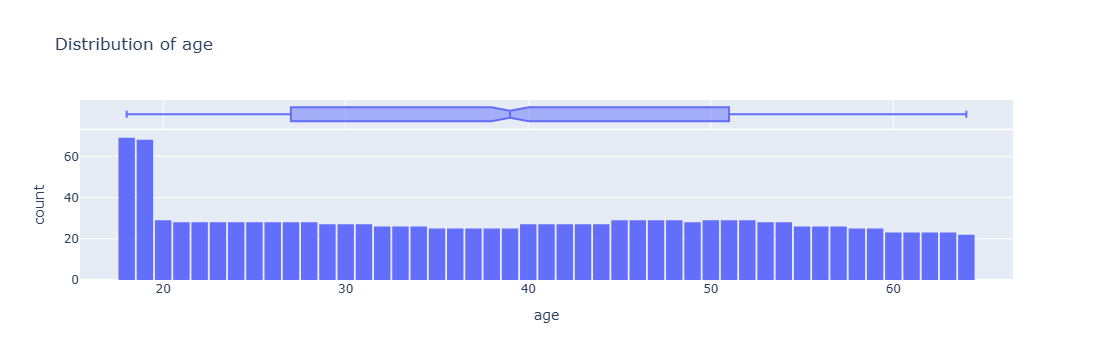

In [8]:
fig = px.histogram(df,x='age',marginal='box',nbins=47,title="Distribution of age")
fig.update_layout(bargap=0.1)
fig.show()

### BMI

In [9]:
df.bmi.describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

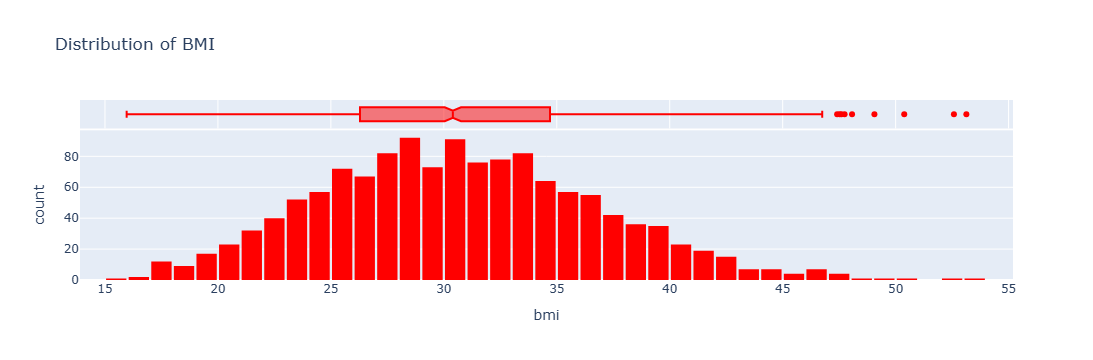

In [10]:
fig = px.histogram(df,x='bmi',marginal='box',color_discrete_sequence=['red'],title="Distribution of BMI")
fig.update_layout(bargap=0.1)
fig.show()

### CHARGES

In [11]:
df.charges.describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

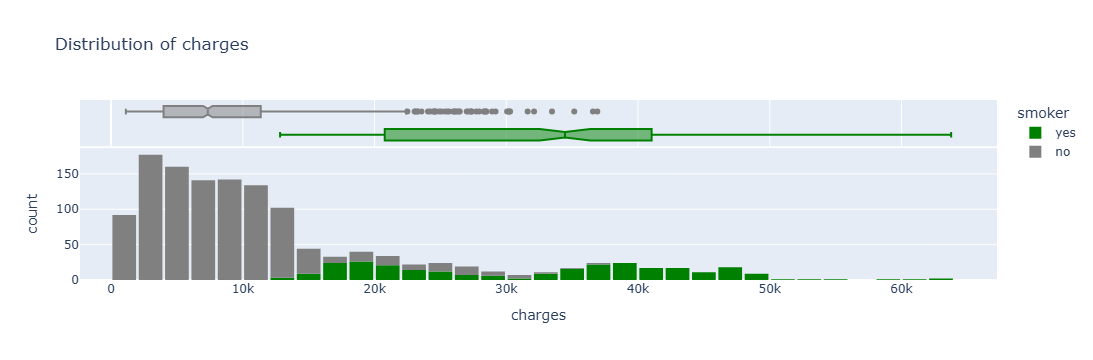

In [12]:
fig = px.histogram(df,x='charges',marginal='box',color='smoker',color_discrete_sequence=['green','grey'],title="Distribution of charges")
fig.update_layout(bargap=0.1)
fig.show()

### SMOKER

In [13]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [14]:
df.smoker.describe()

count     1338
unique       2
top         no
freq      1064
Name: smoker, dtype: object

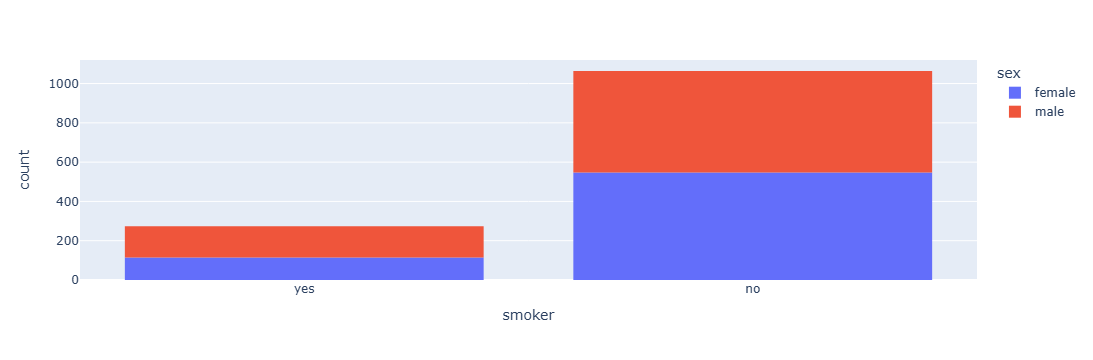

In [15]:
fig = px.histogram(df,x='smoker',color='sex')
fig.show()

### AGE AND CHARGES

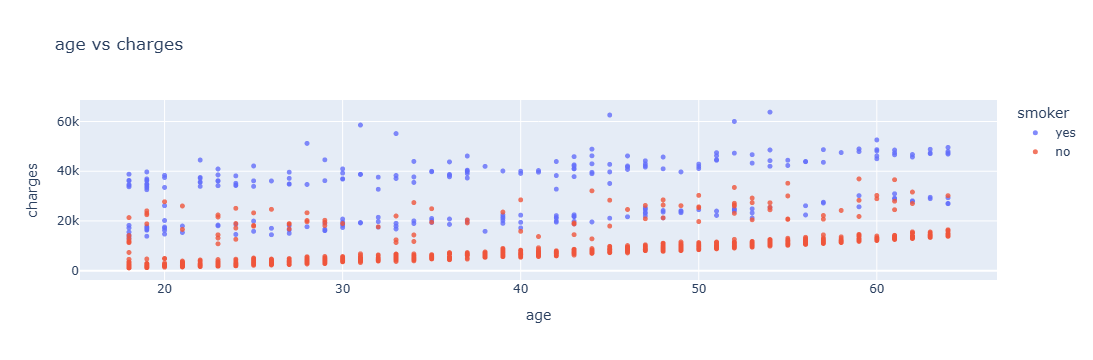

In [16]:
fig = px.scatter(df,x='age',y='charges',color='smoker',hover_data=['sex'],opacity=0.8,title="age vs charges")
fig.update_traces(marker_size=5)
fig.show()

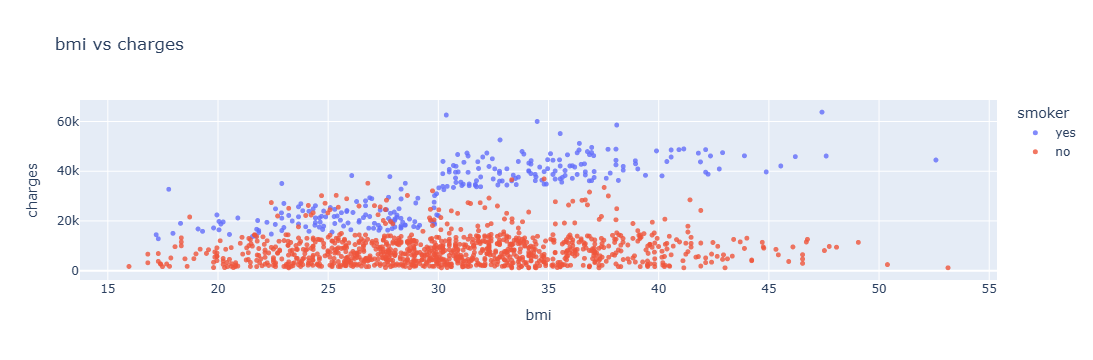

In [17]:
fig = px.scatter(df,x='bmi',y='charges',color='smoker',hover_data=['sex'],opacity=0.8,title="bmi vs charges")
fig.update_traces(marker_size=5)
fig.show()

## CORRELETION

In [18]:
df.charges.corr(df.age)

np.float64(0.2990081933306478)

In [19]:
df.charges.corr(df.bmi)

np.float64(0.19834096883362887)

In [20]:
df.charges.corr(df.charges)

np.float64(1.0)

In [21]:
df.charges.corr(df.children)

np.float64(0.06799822684790487)

In [9]:
s_values={'no':0,'yes':1}
s_numeric=df.smoker.map(s_values)
df.charges.corr(s_numeric)

np.float64(0.7872514304984778)

In [10]:
sex_values ={"female":0,"male":1}
sex_num = df.sex.map(sex_values)
df.charges.corr(sex_num)

np.float64(0.05729206220202533)

In [11]:
sns.heatmap(df.corr(),cmap='red',annot=True)

ValueError: could not convert string to float: 'female'

In [12]:
s_values={'southwest':0,'southeast':1,'northwest':2,'northeast':3}
s_numeric=df.region.map(s_values)
df.charges.corr(s_numeric)


np.float64(0.006208234909444472)

### LINEAR REGRESSION (SINGLE FEATURE)

In [13]:
non_s_df = df[df.smoker == 'no']
non_s_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


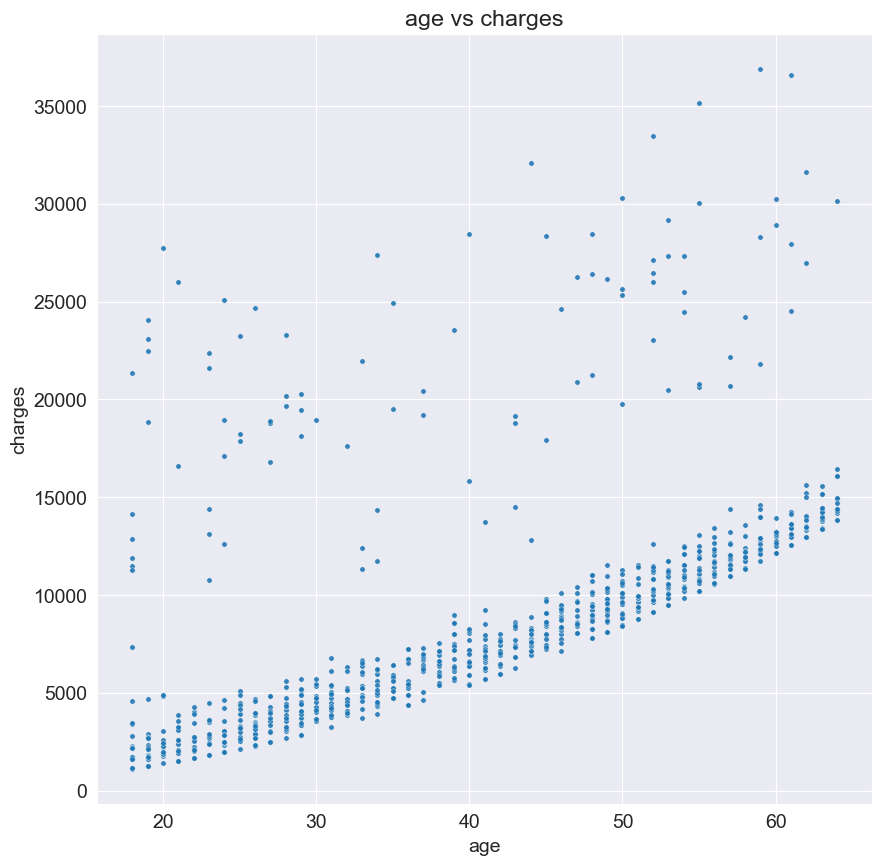

In [14]:
plt.title('age vs charges')
sns.scatterplot(data=non_s_df,x='age',y='charges',alpha=0.9,s=15) #alpha = dot color ,s = dot size
plt.show()

In [15]:
def est_charges(age,w,b):
    return w*age+b

In [16]:
w=50
b=100
est_charges(45,w,b)

2350

In [29]:
ages = non_s_df.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [30]:

estimated_charges = est_charges(ages,w,b)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [31]:
non_s_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

Text(0, 0.5, 'charges')

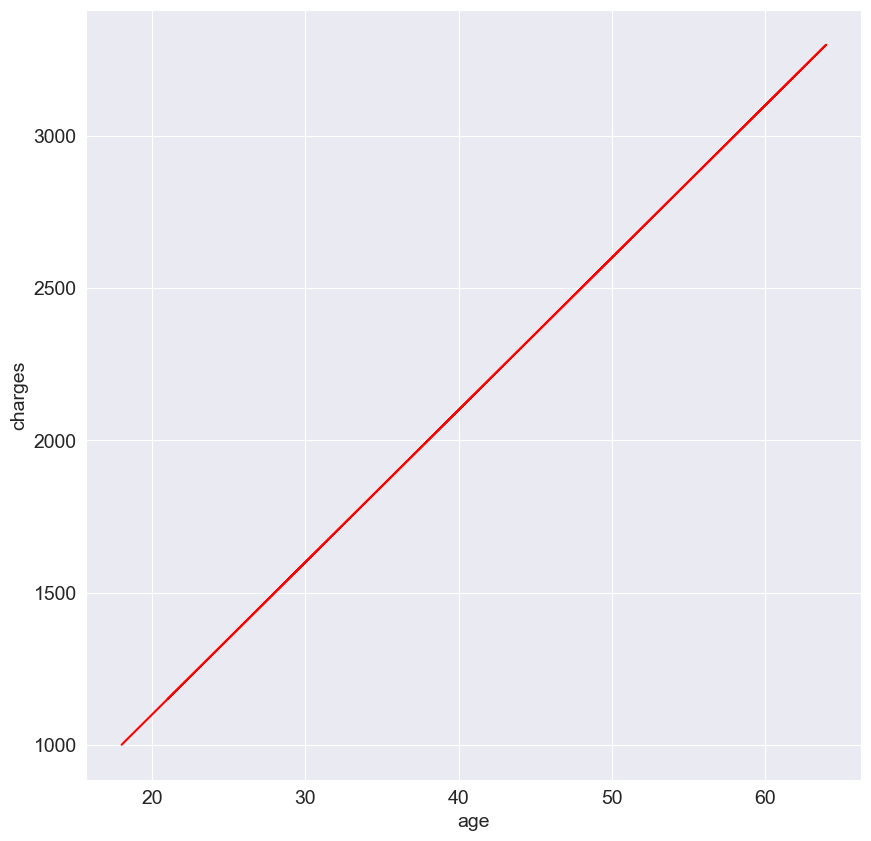

In [32]:
plt.plot(ages,estimated_charges,'r-')
plt.xlabel("age")
plt.ylabel('charges')

Text(0, 0.5, 'charges')

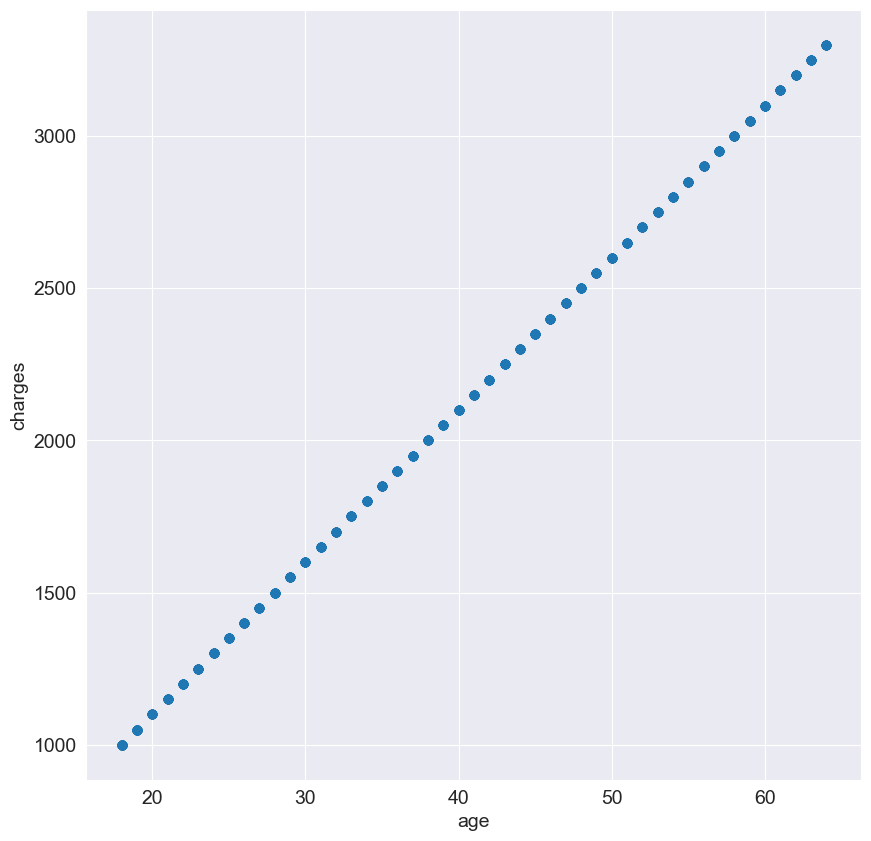

In [33]:
plt.scatter(ages,estimated_charges)
plt.xlabel("age")
plt.ylabel('charges')

C:\Users\arrav\AppData\Local\Temp\ipykernel_2452\39490698.py:6: UserWarning:

Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



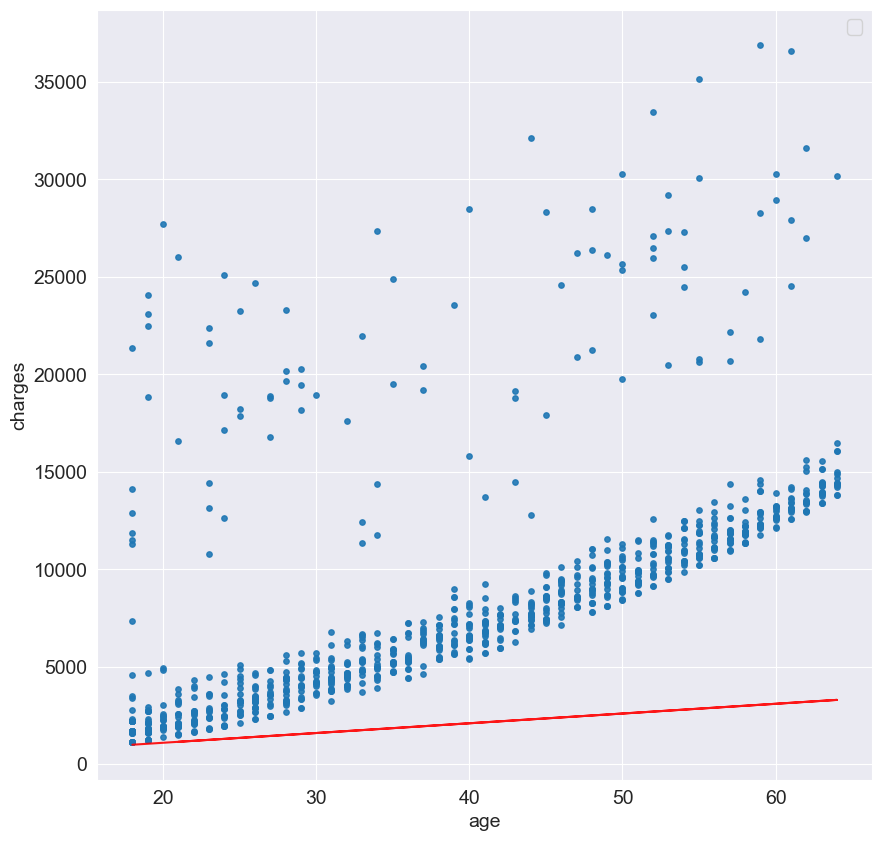

In [34]:
target = non_s_df.charges
plt.plot(ages,estimated_charges,'r',alpha=0.9)
plt.scatter(ages,target,s=15,alpha=0.9)
plt.xlabel("age")
plt.ylabel('charges')
plt.legend('Estimate','Actual')

In [35]:
def try_parameter(w,b):
    ages=non_s_df.age
    target=non_s_df.charges
    
    estimated_charges = est_charges(ages,w,b)

    plt.plot(ages,estimated_charges,'r',alpha=0.9)
    plt.scatter(ages,target,s=15,alpha=0.9)
    plt.xlabel("age")
    plt.ylabel('charges')
    plt.legend(['Estimate','Actual'])


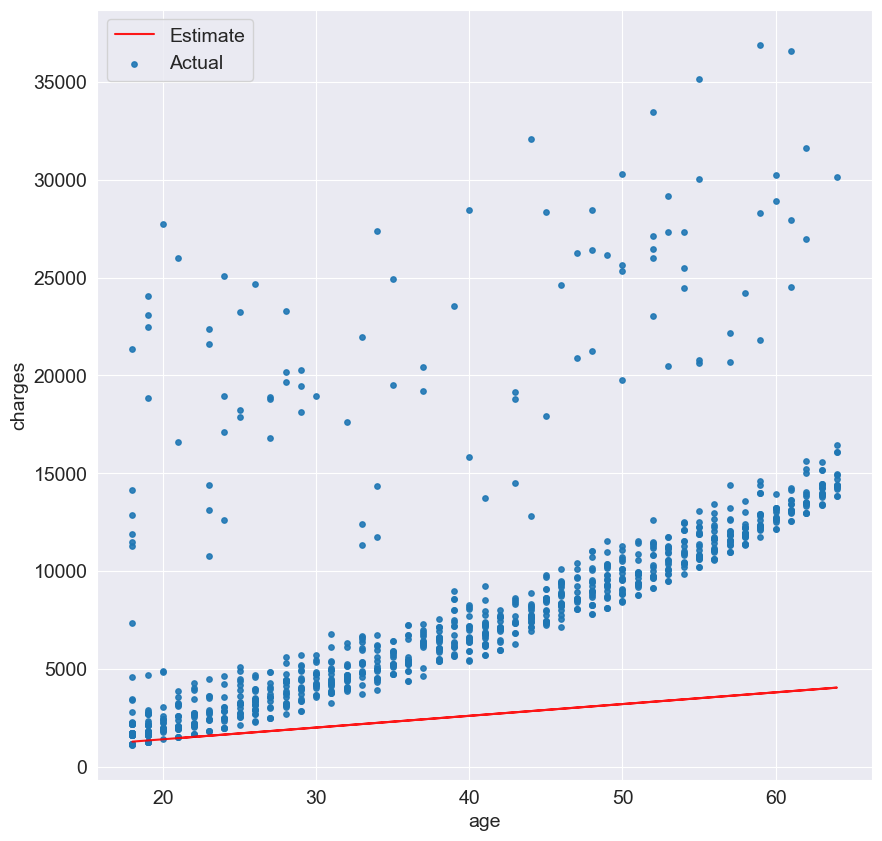

In [36]:
try_parameter(60,200)

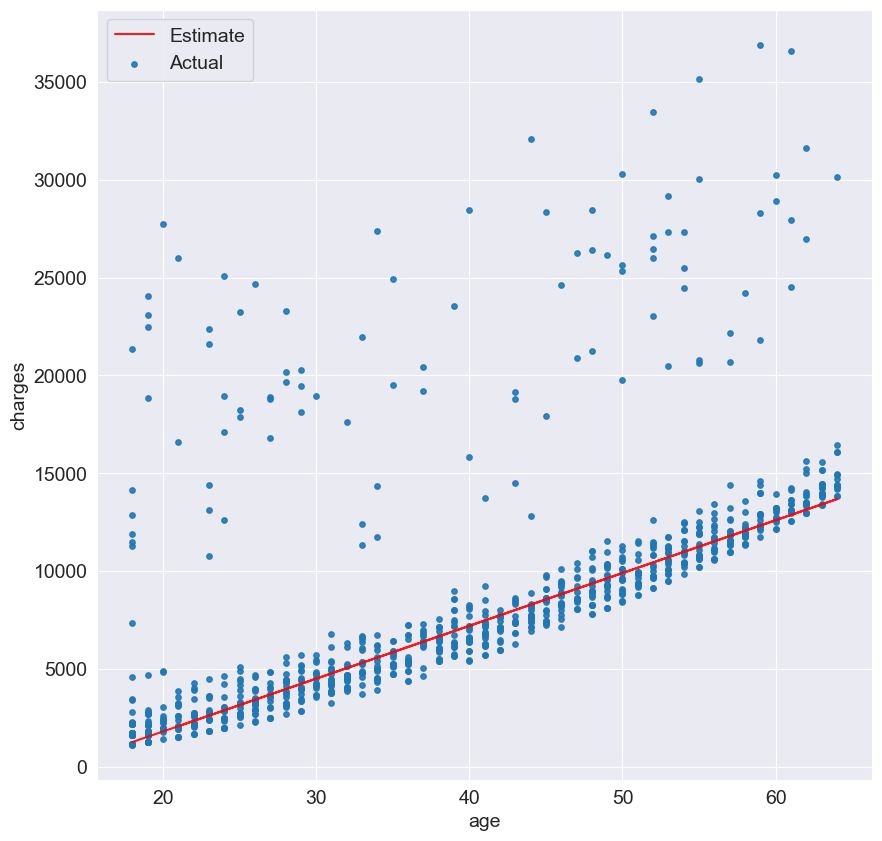

In [37]:
try_parameter(270,-3600) # w=sloop ,b=up and down

### RMSE (root mean square error )

In [38]:
target=non_s_df.charges
def estimated_charges(age,w,b):
    return w*age+b
prediction = estimated_charges

In [39]:
import numpy as np

In [40]:
def rmse(target,prediction):
    return np.sqrt(np.mean(np.square(target-prediction)))

In [41]:
target=non_s_df['charges']
prediction = estimated_charges(non_s_df['age'],w,b)

In [42]:
rmse(target,prediction)

np.float64(8461.949562575493)

In [43]:
def try_parameter(w,b):
    ages=non_s_df.age
    target=non_s_df.charges
    prediction =estimated_charges(ages,w,b)

    plt.plot(ages,prediction,'r',alpha=0.9)
    plt.scatter(ages,target,s=15,alpha=0.9)
    plt.xlabel("age")
    plt.ylabel('charges')
    plt.legend(['prediction','Actual'])
    loss = rmse(target,prediction)
    print("Loss:",loss)


Loss: 4690.343699969419


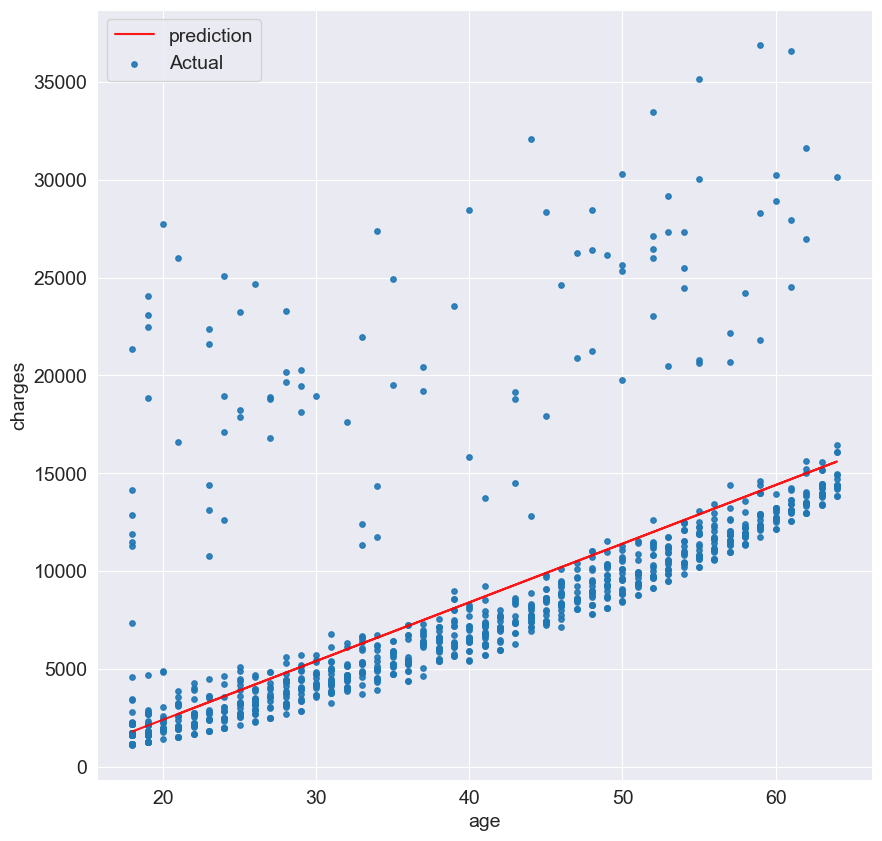

In [44]:
try_parameter(300,-3600)

### sklearn

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model=LinearRegression()

In [47]:
inputs = non_s_df[['age']]
target = non_s_df.charges
model.fit(inputs,target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
model.predict([[23],[56],[61]])

C:\Users\arrav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855, 12874.51856198, 14210.76312614])

In [49]:
predictions = model.predict(inputs)

In [50]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [51]:
target

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [52]:
rmse(target,predictions)

np.float64(4662.505766636395)

In [53]:
#w
model.coef_

array([267.24891283])

In [54]:
#b
model.intercept_

np.float64(-2091.4205565650864)

Loss: 4662.505766636395


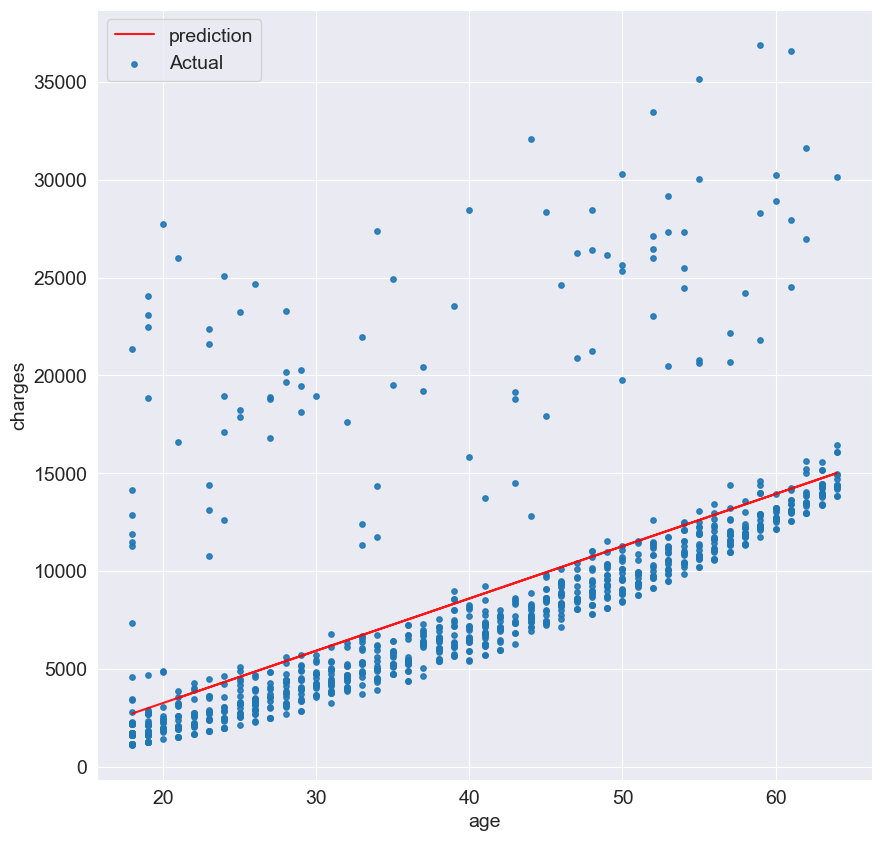

In [55]:
try_parameter(model.coef_,model.intercept_)

In [20]:
#input and target
inputs,target = non_s_df[['age']],non_s_df['charges']
#model
model = LinearRegression().fit(inputs,target)
#prediction
prediction = model.predict(inputs)
loss = rmse(target,prediction)
print("loss",loss)

NameError: name 'rmse' is not defined

### smoker

In [57]:
smoker_df = df[df.smoker == 'yes']
smoker_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630


In [58]:
inputs,target = smoker_df[['age']],smoker_df['charges']
model = LinearRegression().fit(inputs,target)
prediction = model.predict(inputs)
loss = rmse(prediction,target)
print('loss',loss)

loss 10711.00334810241


### MULTIPLE FEATURE

In [59]:
inputs,target = non_s_df[['age','bmi']],non_s_df['charges']
model = LinearRegression().fit(inputs,target)
prediction = model.predict(inputs)
loss = rmse(prediction,target)
print('loss',loss)

loss 4662.3128354612945


In [60]:
non_s_df.charges.corr(non_s_df.bmi)

np.float64(0.08403654312833271)

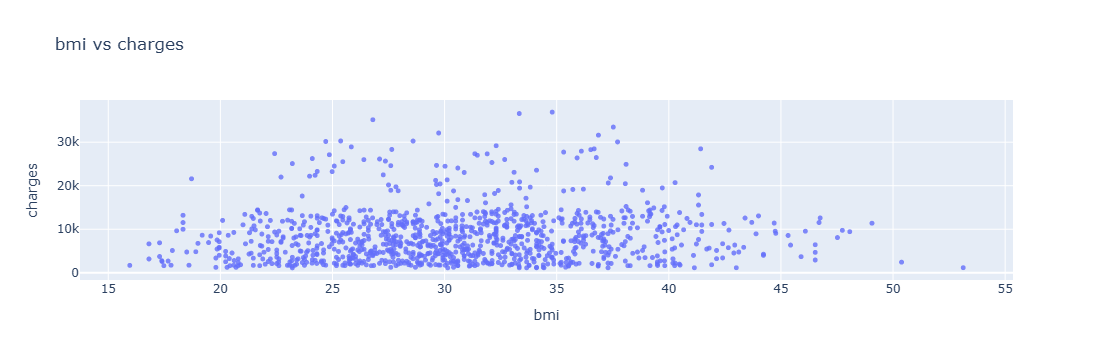

In [61]:
fig = px.scatter(non_s_df,x='bmi',y='charges',opacity=0.8,title="bmi vs charges")
fig.update_traces(marker_size=5)
fig.show()

In [62]:
non_s_df.charges.corr(non_s_df.children)

np.float64(0.13892870453542205)

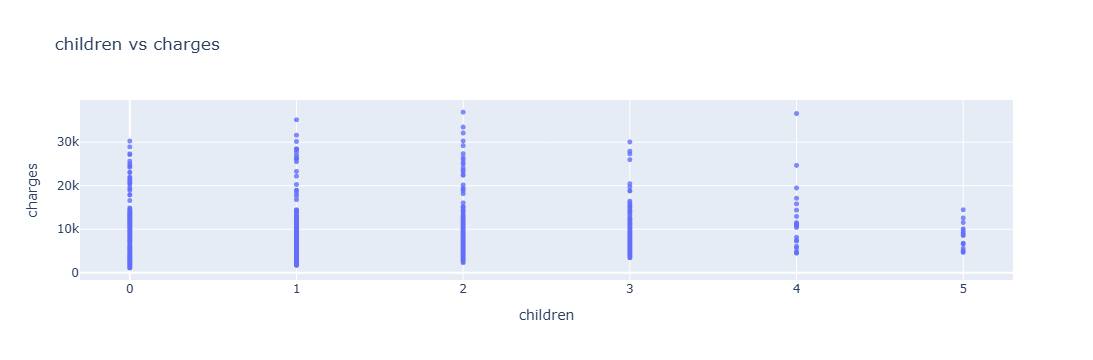

In [63]:
fig = px.scatter(non_s_df,x='children',y='charges',opacity=0.8,title="children vs charges")
fig.update_traces(marker_size=5)
fig.show()

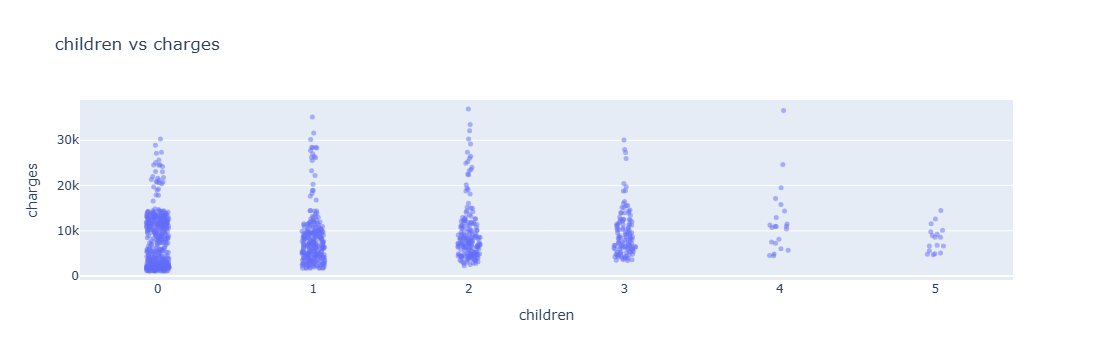

In [64]:
fig = px.strip(non_s_df,x='children',y='charges',title="children vs charges")
fig.update_traces(marker_size=5,marker_opacity=0.5)
fig.show()

In [65]:
inputs,target = non_s_df[['age','bmi','children']],non_s_df['charges']
model = LinearRegression().fit(inputs,target)
prediction = model.predict(inputs)
loss = rmse(prediction,target)
print('loss',loss)

loss 4608.470405038246


### original dataset

In [66]:
inputs,target = df[['age','bmi','children']],df['charges']
model = LinearRegression().fit(inputs,target)
prediction = model.predict(inputs)
loss = rmse(prediction,target)
print('loss',loss)

loss 11355.317901125973


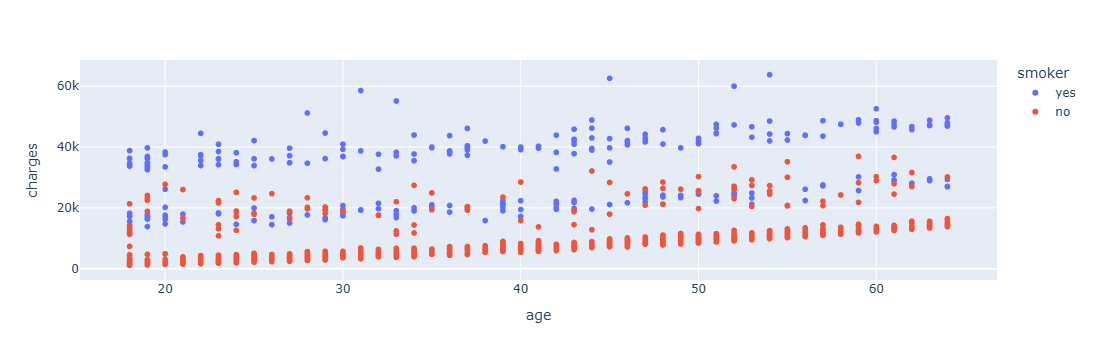

In [67]:
fig = px.scatter(df,x='age',y='charges',color='smoker')
fig.show()

### CATEGORICAL COLUMN

#### binary

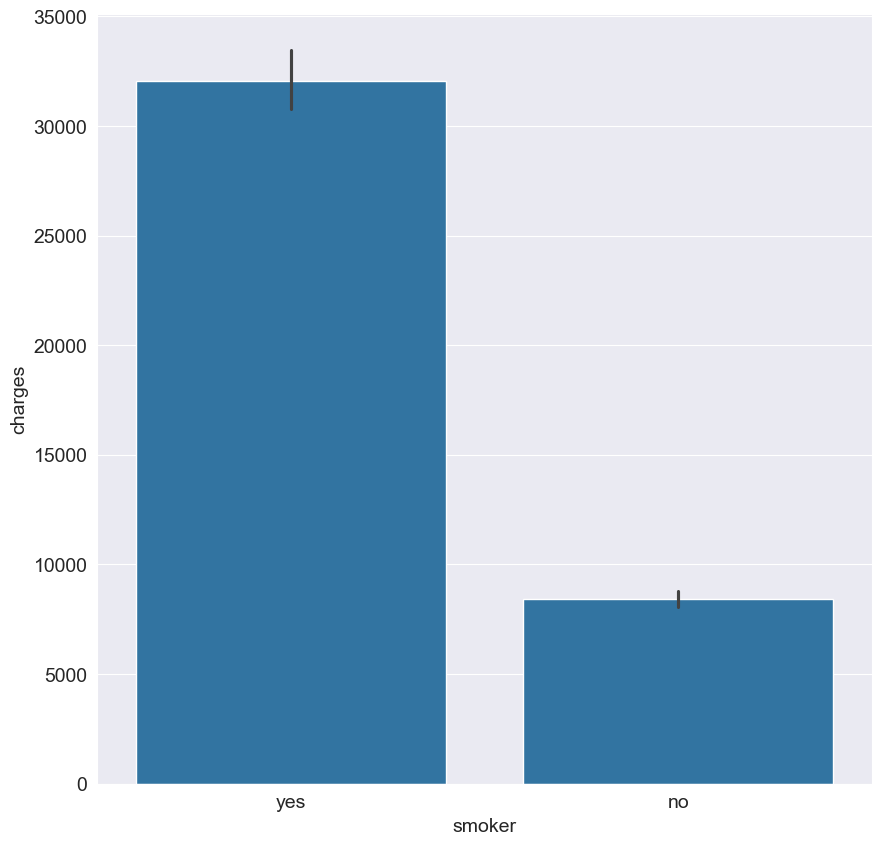

In [68]:
sns.barplot(data=df,x='smoker',y='charges');

In [69]:
smoker_codes ={ 'no':0,'yes':1}
df['smoker_codes']=df.smoker.map(smoker_codes)

In [70]:
df.charges.corr(df.smoker_codes)

np.float64(0.7872514304984778)

In [71]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [21]:
inputs,target = df[['age','bmi','children','smoker_codes']],df['charges']
model = LinearRegression().fit(inputs,target)
prediction = model.predict(inputs)
loss = rmse(target,prediction)
print("loss",loss)

KeyError: "['smoker_codes'] not in index"

In [73]:
sex_codes ={ 'female':0,'male':1}
df['sex_codes']=df.sex.map(sex_codes)

In [74]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_codes,sex_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [75]:
df.charges.corr(df.sex_codes)

np.float64(0.05729206220202533)

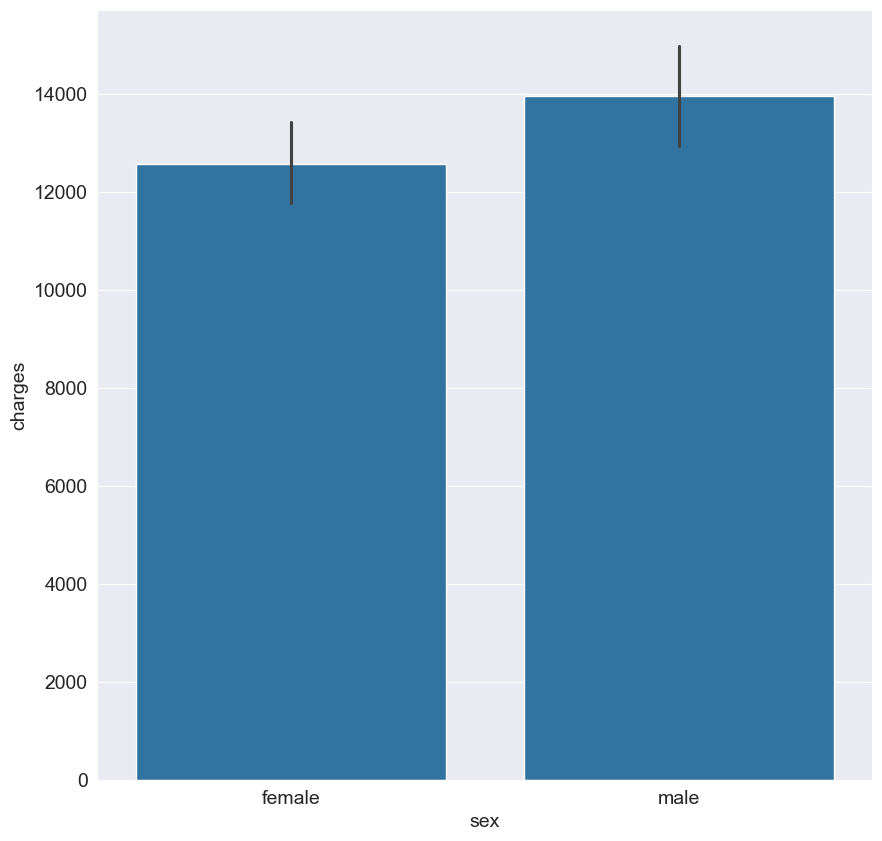

In [76]:
sns.barplot(data=df,x='sex',y='charges');

In [77]:
inputs,target = df[['age','bmi','children','smoker_codes','sex_codes']],df['charges']
model = LinearRegression().fit(inputs,target)
prediction = model.predict(inputs)
loss = rmse(target,prediction)
print("loss",loss)

loss 6056.100708754546


### one hot encoder

In [78]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [79]:
enc.transform([['northeast']]).toarray()

C:\Users\arrav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but OneHotEncoder was fitted with feature names



array([[1., 0., 0., 0.]])

In [80]:
one_hot = enc.transform(df[['region']]).toarray()

In [81]:
df[['northeast','northwest','southeast','southwest']] = one_hot

In [82]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_codes,sex_codes,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [83]:
inputs,target = df[['age','bmi','children','smoker_codes','sex_codes','northeast','northwest','southeast','southwest']],df['charges']
model = LinearRegression().fit(inputs,target)
prediction = model.predict(inputs)
loss = rmse(target,prediction)
print("loss",loss)

loss 6041.6796511744515


### Scaler

In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler

In [97]:
num_cols=['age','bmi','children']
scaler = StandardScaler()
scaler.fit(df[num_cols])

,copy,True
,with_mean,True
,with_std,True


In [98]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [99]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [104]:
scaled_input = scaler.transform(df[num_cols])
scaled_input

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))

In [105]:
cat_input = ['smoker_codes','sex_codes','northeast','northwest','southeast','southwest']
cat_data = df[cat_input].values
cat_data

array([[1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 0.]], shape=(1338, 6))

In [110]:
inputs = np.concatenate((scaled_input,cat_data),axis=1)
inputs[0]

array([-1.43876426, -0.45332   , -0.90861367,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ])

In [111]:
target= df['charges']
target

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [112]:
model = LinearRegression().fit(inputs,target)
prediction = model.predict(inputs)
loss = rmse(target,prediction)
print("loss",loss)

loss 6041.679651174452


In [114]:
weights_df=pd.DataFrame({
    'features':np.append(num_cols+cat_input,1),
    'weight':np.append(model.coef_,model.intercept_)
})
weights_df.sort_values('weight',ascending=False)

,features,weight
3,smoker_codes,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_codes,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


In [ ]:
new_customer = [[28,30,2,1,0,0,1,0,0.]]


In [119]:
scaler.transform([[28,30,2]])

C:\Users\arrav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



array([[-0.79795355, -0.10882659,  0.75107928]])

In [121]:
model.predict([[-0.79795355, -0.10882659,  0.75107928,1,0,0,1,0,0.]])

array([29875.81463371])

### train test

In [122]:
from sklearn.model_selection import train_test_split

In [123]:
input_train,input_test,target_train,target_test = train_test_split(inputs,target,test_size=0.1)

In [131]:
model=LinearRegression().fit(input_train,target_train)

In [132]:
prediction_test = model.predict(input_test)
loss=rmse(target_test,prediction_test)
print("loss",loss)

loss 5613.510328033503


In [134]:
prediction_train = model.predict(input_train)
loss = rmse(target_train,prediction_train)
loss

np.float64(6088.9817099966385)